In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

## Data Wrangling
# Gathering Data

In [2]:
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')

print(day_df.head())
print(hour_df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
   instant      dteday  se

## Assessing Data
# Mengecek Informasi Dataset

In [3]:
print(day_df.info())
print(hour_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns

# Mengecek Missing Value

In [4]:
print(day_df.isna().sum())
print(hour_df.isna().sum())

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


# Mengecek Duplicate Data

In [5]:
print(day_df.duplicated().sum())
print(hour_df.duplicated().sum())

0
0


# Mengecek Statistik Deskriptif

In [6]:
print(day_df.describe())
print(hour_df.describe())

          instant      season          yr        mnth     holiday     weekday  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean   366.000000    2.496580    0.500684    6.519836    0.028728    2.997264   
std    211.165812    1.110807    0.500342    3.451913    0.167155    2.004787   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.500000    2.000000    0.000000    4.000000    0.000000    1.000000   
50%    366.000000    3.000000    1.000000    7.000000    0.000000    3.000000   
75%    548.500000    3.000000    1.000000   10.000000    0.000000    5.000000   
max    731.000000    4.000000    1.000000   12.000000    1.000000    6.000000   

       workingday  weathersit        temp       atemp         hum   windspeed  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     0.683995    1.395349    0.495385    0.474354    0.627894    0.190486   
std      0.465233    0.5448

## Permasalahan Data yang Ditemukan
1. Terdapat tipe data tanggal yang masih berbentuk object.
2. Terdapat beberapa kolom kategorikal yang masih berbentuk angka sehingga kurang informatif.

## Cleaning Data
# Mengubah Tipe Data Tanggal

In [7]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mengubah Label Season

In [8]:
season_map = {
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
}

day_df['season'] = day_df['season'].map(season_map)
hour_df['season'] = hour_df['season'].map(season_map)

# Mengubah Label Weather

In [9]:
weather_map = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
}

day_df['weathersit'] = day_df['weathersit'].map(weather_map)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_map)

## Exploratory Data Analysis (EDA)
# Pertanyaan 1: Pengaruh Cuaca terhadap Penyewaan Sepeda
Insight
Cuaca cerah memiliki jumlah penyewaan tertinggi.
Cuaca buruk menyebabkan penurunan jumlah pengguna.

In [10]:
weather_rentals = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)
print(weather_rentals)

weathersit
Clear              4876.786177
Mist               4035.862348
Light Snow/Rain    1803.285714
Name: cnt, dtype: float64


# Pertanyaan 2: Jam Penyewaan Tertinggi pada Hari Kerja
Insight
Jam sibuk terjadi pada pagi dan sore hari.
Pola menunjukkan aktivitas commuting.

In [11]:
workingday_hour = hour_df[hour_df['workingday'] == 1]
peak_hour = workingday_hour.groupby('hr')['cnt'].mean()
print(peak_hour)

hr
0      36.786290
1      16.552632
2       8.683778
3       4.942553
4       5.429787
5      24.913131
6     102.500000
7     290.612903
8     477.006048
9     241.518145
10    135.366935
11    158.229839
12    200.820926
13    198.429719
14    183.572289
15    201.331325
16    293.122244
17    525.290581
18    492.226908
19    348.401606
20    249.718876
21    186.287149
22    138.389558
23     88.708835
Name: cnt, dtype: float64


## Visualization & Explanatory Analysis
# Visualisasi 1: Pengaruh Cuaca terhadap Jumlah Penyewaan
Kesimpulan

Jumlah penyewaan tertinggi terjadi saat cuaca cerah, sedangkan cuaca buruk menyebabkan penurunan signifikan.

/tmp/ipykernel_4463/2122405649.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weather_rentals.index,


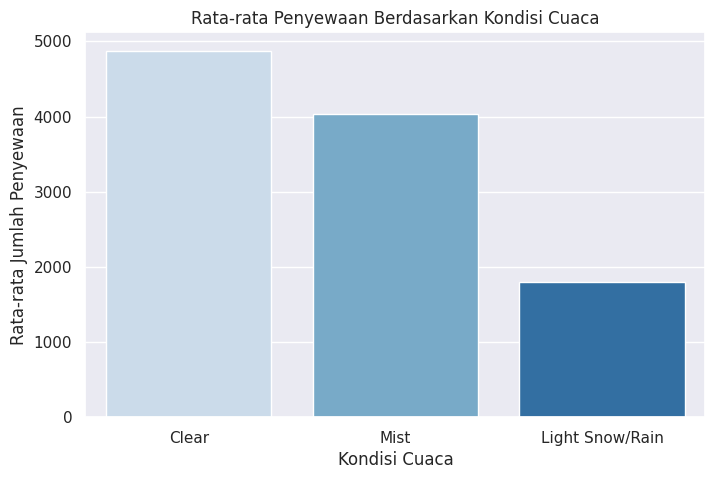

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x=weather_rentals.index,
            y=weather_rentals.values,
            palette='Blues')

plt.title('Rata-rata Penyewaan Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

# Visualisasi 2: Pola Penyewaan Berdasarkan Jam
Kesimpulan

Aktivitas penyewaan paling tinggi terjadi pada jam berangkat dan pulang kerja.

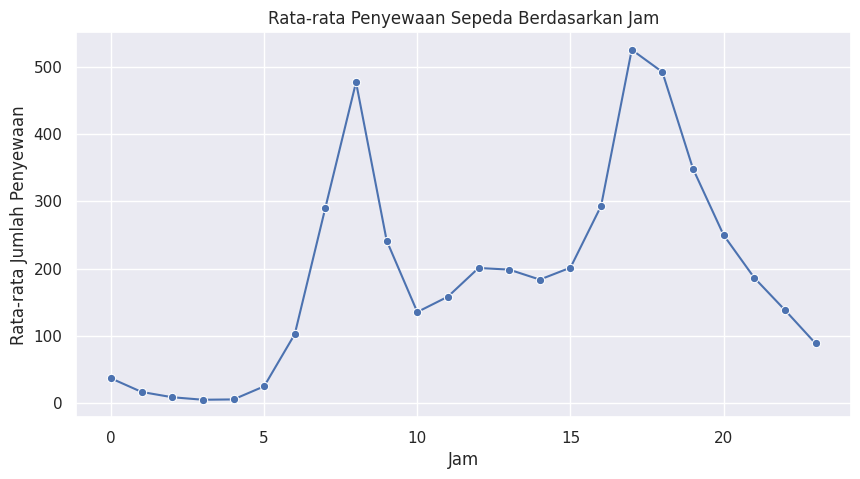

In [13]:
plt.figure(figsize=(10,5))
sns.lineplot(x=peak_hour.index,
             y=peak_hour.values,
             marker='o')

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.show()

In [14]:
# Menyimpan dataframe ke CSV
day_df.to_csv('day_clean.csv', index=False)
hour_df.to_csv('hour_clean.csv', index=False)

print("File CSV berhasil disimpan!")

File CSV berhasil disimpan!


In [1]:
!pip freeze > /content/requirements.txt

The system cannot find the path specified.
